# Supervised Learning

Machine Learning is broadly split into two kinds of learning: supervised learning in which the agent is given some set of inputs $X$ and corresponding outputs $Y$ and must learn to map $X \to Y$, and unsupervised learning in which the agent only recieves inputs $X$ and must achieve some other goal.

An example of a supervised learning is image recognition: if we have a database of thousands of images of cats and dogs each labelled "0" for cat and "1" for dog", we can train a model to go from an image to a prediction of whether that image contains a cat or a dog. The images are our data $X$ and the predicitons are our labels $Y$.

The simplest supervised learning task is linear regression. Suppose we have some data Y = f(X), we can draw a line such that for any new $x \in X$ we can predict the corresponding $y \in Y$. First, let's generate some data. We'll generate our points using $y = mx + b + R$ where $m$ is the gradient, $b$ is the y-intersect, and $R$ is a random factor. We'll put m and b aside and try to guess them!

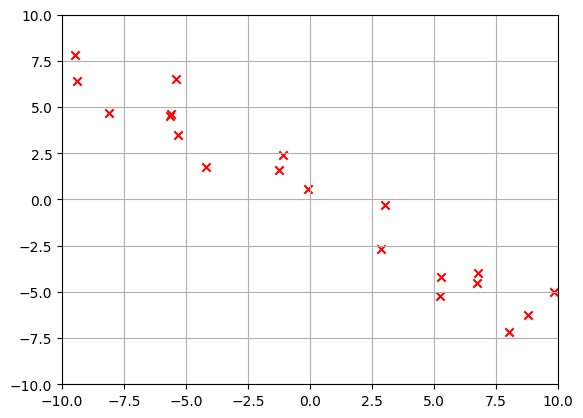

In [1]:
import random as r
import matplotlib.pyplot as plt
import numpy as np
r.seed(1)
real_m = r.uniform(-1, 1)
real_b = r.uniform(-1, 1)

def line(x, m = real_m, b = real_b, R = 2.1):
    return(m*x + b + r.uniform(-R, R))

#Let's make some data:
num_points = 20
data = []
for i in range(num_points):
    x = r.uniform(-10, 10)
    data.append([x, line(x)])
    plt.scatter(data[i][0], data[i][1], color = "red", marker = "x")
plt.grid(True)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.show()

# Linear Regression

So we have our data set and we know our line is in the form $y = mx + b + R$. We can define a loss function $L(m, b)$ which tells us how wrong our guesses for $m$ and $b$ are, and use random search to predict the correct gradient and intersect. When we are done we will have completed a linear regression, finding the best line to fit the data

In [2]:
num_iterations = 100000

def loss(solution, data):
    output = 0
    for point in data:
        #Below is the "mean squared error"
        output += (point[0] * solution[0] + solution[1] - point[1]) ** 2
    return(output)

best_m = 0
best_b = 0
best_loss = 10 ** 10
for i in range(num_iterations):
    guessed_m = r.uniform(-1, 1)
    guessed_b = r.uniform(-1, 1)
    if loss([guessed_m, guessed_b], data) < best_loss:
        best_m = guessed_m
        best_b = guessed_b
        best_loss = loss([guessed_m, guessed_b], data)
print(f"Random search found m = {best_m} and b = {best_b}, actual values were m = {real_m}, b = {real_b}")

Random search found m = -0.7184765319132806 and b = 0.28873139095983436, actual values were m = -0.7312715117751976, b = 0.6948674738744653


# Building a model

So now we have an estimate for $m$ and $b$ let's build our model. Our model $M$ maps $X \to Y$, so for any $x \in X$ we can call model.predict and get a corresponding $y \in Y$. Let's be fancy and call our predicted values "weights" and set up our model as a class. The reason we do this will become clear later in the course.

In [3]:
weights = [best_m, best_b]
class model:
    def __init__(self, weights):
        self.m = weights[0]
        self.b = weights[1]
    def predict(self, x):
        return(self.m * x + self.b)
model1 = model(weights)

# Plotting results

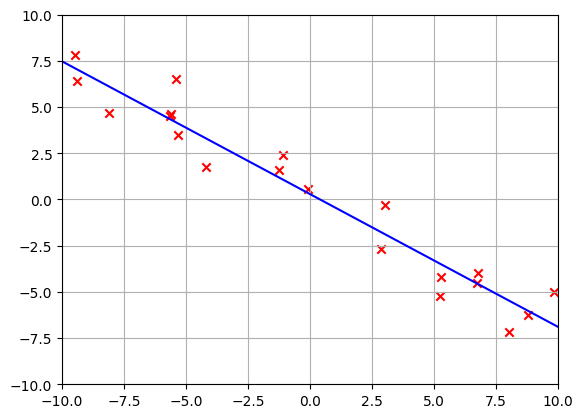

In [4]:
for i in range(num_points):
    plt.scatter(data[i][0], data[i][1], color = "red", marker = "x")
x_data = np.linspace(-10, 10, 100)
y_data = [model1.predict(x) for x in x_data]
plt.plot(x_data, y_data, color = "blue")
plt.grid(True)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.show()

# Task: Polynomial Regression

In this notebook we have generated data and performed a linear regression: that is, we found $m$ and $b$ such that our fit of $y(x) = mx + b$ leaves the smallest gap between our predicted $y(x)$ and our empirical $Y$. Your task is to extend this to a general polynomial fit. We will have a set of weights $W = (w_0, w_1, ... , w_n)$ and we will fit $y(x) = w_0 + w_1 x + w_2 x^2 ... w_n x^n$ to $Y$. 

Some tips:

- for large numbers of dimensions, random search may be inefficient. Consider checking the optimization module if your model fails to find a good fit, there may be better options for an optimization algorithm.

- try not to peek at the code which generates the data, you will learn more if you figure out the problem authentically!

- consider what happens if you use too many terms, or too few. If you want a hint, look up "overfitting" and "underfitting".

### Code for task (no peeking: data is printed after the code!)

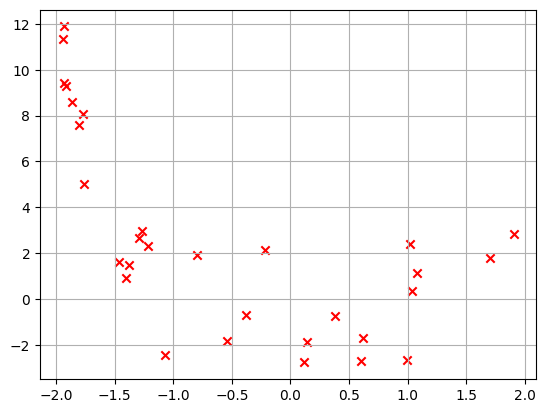

In [5]:
def polynomial(x, weights, R = 3):
    return(r.uniform(-R, R) + sum(weights[i] * x ** i for i in range(len(weights))))
chosen_ms = [r.uniform(-1, 1) for x in range(5)]

#Let's make some data:
num_points = 30
data = []
for i in range(num_points):
    x = r.uniform(-2, 2)
    data.append([x, polynomial(x, chosen_ms)])
    plt.scatter(data[i][0], data[i][1], color = "red", marker = "x")
plt.grid(True)
plt.show()

# Data

In [6]:
print(data)

[[-1.7570813522475675, 4.995132122749673], [0.6008317106434369, -2.731188558979289], [1.0750115093332018, 1.1292179225395864], [-1.912595480970527, 9.314276580501662], [0.3765614498673089, -0.768859768503808], [1.6986783175971731, 1.8027693770321904], [-1.4057900293808818, 0.9302545140191729], [0.6195851128567433, -1.6961477258317594], [0.9903963708869821, -2.6898974840486303], [-0.7934629487153173, 1.9004384322929684], [-1.8070456527105212, 7.570938858140549], [-1.9430508169000569, 11.348370818540866], [-1.9272843254070096, 11.894312746468923], [-1.2138828591174065, 2.308062911147407], [-1.295632894436273, 2.676653141466396], [-1.0722479364575812, -2.434291998493226], [1.0190204358933843, 2.4071311833384836], [-0.37889812451077676, -0.6844706299284482], [1.0371422089741351, 0.3408051508905463], [-1.8611724882033434, 8.593796309052262], [1.902433980466371, 2.8174745462542585], [-0.5449452524092155, -1.8488022987327146], [-0.21870522932216252, 2.135156933485523], [-1.2689065461390157, 2